In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset
df = pd.read_csv("energy_production_shutdown.csv")

# Preview dataset
df.head()

,date,production
0,2012-01-01,375.1
1,2012-01-02,474.5
2,2012-01-03,573.9
3,2012-01-04,539.5
4,2012-01-05,445.4


In [8]:
# Check dataset structure
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1095 non-null   str    
 1   production  1095 non-null   float64
dtypes: float64(1), str(1)
memory usage: 27.9 KB


date          0
production    0
dtype: int64

In [9]:
# Fill missing numeric values with column mean
df = df.fillna(df.mean(numeric_only=True))


In [10]:
df.columns = df.columns.str.strip()  # removes spaces

In [11]:
print(df.columns)

Index(['date', 'production'], dtype='str')


In [12]:
print(df.head())

         date  production
0  2012-01-01       375.1
1  2012-01-02       474.5
2  2012-01-03       573.9
3  2012-01-04       539.5
4  2012-01-05       445.4


In [18]:
print(df.columns)

Index(['date', 'production'], dtype='str')


In [21]:
print('y_test' in globals())
print('y_pred_dt' in globals())

False
False


In [26]:
plt.show()

In [31]:
df.head()

,date,production
0,2012-01-01,375.1
1,2012-01-02,474.5
2,2012-01-03,573.9
3,2012-01-04,539.5
4,2012-01-05,445.4


             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


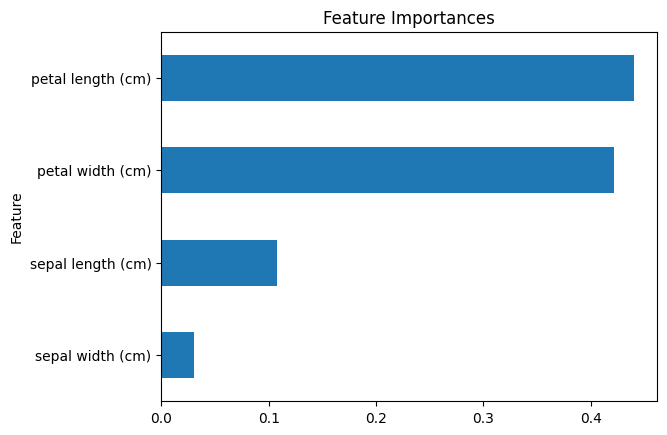

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Load example dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Feature importances
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Plot
feature_importance_df.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.show()

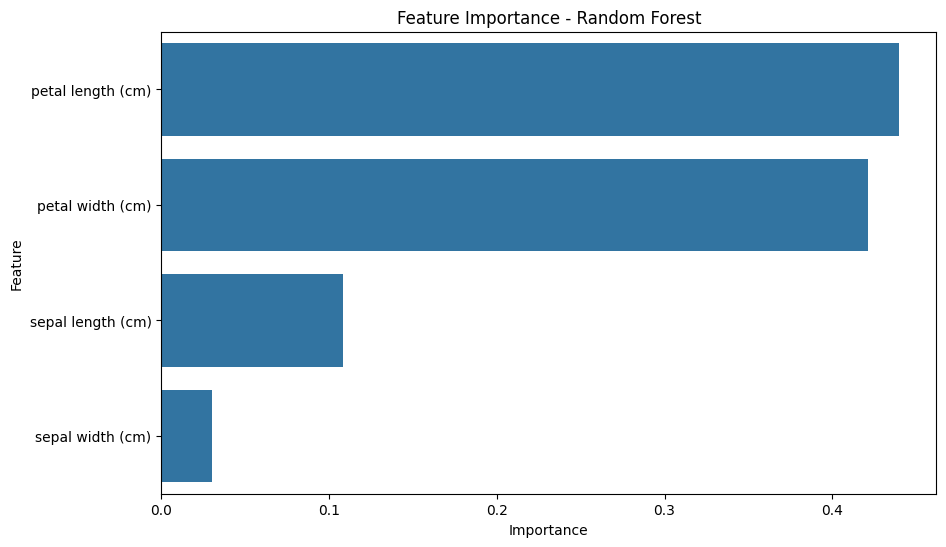

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)

plt.title("Feature Importance - Random Forest")
plt.show()